# Starting Kit - FAIR UNIVERSE: HIGGSML UNCERTAINTY CHALLENGE

For Overview and Descriptions of the competition, please visit the [competition page](https://www.codabench.org/competitions/2977/)

`COLAB` determines whether this notebook is running on Google Colab.
For local setup check : [Local Setup](./pages/Local_setup.md)

In [1]:
COLAB = 'google.colab' in str(get_ipython())

In [2]:
if COLAB:
    # clone github repo
    !git clone --depth 1 https://github.com/FAIR-Universe/HEP-Challenge.git

    # move to the HEP starting kit folder
    %cd HEP-Challenge/

    # Install required packages
    # %pip install -r conda/requirements.txt 

### Dummy_Submission
By this point you should have a clone of the repo which contains `HiggsML_Dummy_Submission.zip` which you can submit to the Competition

### Imports

In [3]:
# Standard library imports
import datetime
import json
import os
from contextlib import closing
from sys import path
from zipfile import ZipFile, ZIP_DEFLATED

# Third-party imports
import numpy as np


### Directories

In [4]:

root_dir = os.getcwd()
print("Root directory is", root_dir)

# The directory of the input data
input_dir = os.path.join(root_dir, "input_data")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission") 

# The directory of the ingestion program 
program_dir = os.path.join(root_dir, "ingestion_program") 

# The directory of the scoring program
score_dir = os.path.join(root_dir, "scoring_program")
submission_dir = os.path.join(root_dir, "sample_submission")

# Add the directory to the path
path.append(program_dir) 
path.append(score_dir)
path.append(submission_dir)

Root directory is /home/chakkappai/Work/Fair-Universe/HEP-Challenge


In [5]:
from systematics import systematics # import the systematics function from the ingestion program

***
## Data
***

⚠️ Note:

By default the repository has a sample dataset at [input_data](./input_data/). This is a small sample data is for demonstration only to get a view of what the data looks like.

For Training and inference you may want to use the much Bigger public dataset. For this set `USE_PUBLIC_DATASET` to `True` and the code below uses the  `Neurips2024_public_dataset()` funtion in the `dataset` module to download and read the public dataset. else the code loads the small sample data for quick execution of this notebook


⚠️ Note:

If you have already downloaded the public_data from the competition website, make sure that it is placed in the right folder `HEP-Challenge/` so that you don't download it again. Setting `USE_PUBLIC_DATASET` to `True` will download the public_data if not found in the `HEP-Challenge` directory.

In [6]:
USE_PUBLIC_DATASET = False

`USE_PUBLIC_DATASET` determines whether to use a public dataset provided for the participants or use a small subset of the data for quick execution of this notebook

In [7]:
from datasets import Data # import the Data class from the ingestion program

if USE_PUBLIC_DATASET:
    from datasets import Neurips2024_public_dataset as public_dataset
    data = public_dataset()
else:
    data = Data(input_dir)

2025-10-15 14:12:24,217 - datasets             - INFO     - Total rows: 1000
2025-10-15 14:12:24,217 - datasets             - INFO     - Test size: 300


The function loads the downloaded data in the public_data folder or downloads the data from codabench using `request` from zenodo in the absence of the downloaded data, 

In [8]:
# load train set
data.load_train_set(train_size=500) # load the training set to memory, this may take a few seconds
data_vis = data.get_train_set()

print(data_vis.shape)


2025-10-15 14:12:24,222 - datasets             - INFO     - Selected train size: 500
2025-10-15 14:12:24,234 - datasets             - INFO     - Data loaded successfully


(500, 31)


***
## Visualize
***
The purpose of the `Dataset_visualise` class is to visulaise the training dataset,
data is the dictionary of different fields like dataframe, label, weights etc. upon initiallisation you will see a table of these fields

Initialisation you can give a list a columns of Data you are interested to have plots for. If no inputs are given then all the columns of the DataFrame are taken

In [9]:
import visualization as viz
 
# when No systematics parameters are passed, the systematics function will return the original dataset with post process cuts
data_vis = systematics(data_vis) 
train_visualize = viz.Dataset_visualise(
    data_set=data_vis,
    columns=[
        "PRI_met",
        "PRI_had_pt",
        "DER_mass_vis",
        "PRI_jet_leading_eta",
        "DER_mass_transverse_met_lep",
        "DER_deltar_had_lep",

    ],
    name="Train Set",
)


General Structure of the data object is a dictionary
+-----------------------------+-----------------------+-------------------------------------+
| Key                         | Value                 | Type                                |
+=============================+=======================+=====================================+
| PRI_lep_pt                  | Array of shape (458,) | <class 'pandas.core.series.Series'> |
+-----------------------------+-----------------------+-------------------------------------+
| PRI_lep_eta                 | Array of shape (458,) | <class 'pandas.core.series.Series'> |
+-----------------------------+-----------------------+-------------------------------------+
| PRI_lep_phi                 | Array of shape (458,) | <class 'pandas.core.series.Series'> |
+-----------------------------+-----------------------+-------------------------------------+
| PRI_had_pt                  | Array of shape (458,) | <class 'pandas.core.series.Series'> |
+-----

The `examine_dataset` methods give you more general infomation as tables to give an idea of the general nature of the training data

In [10]:
# Show data summary
train_visualize.examine_dataset()


+--------------------+-----------+
| Key                | Value     |
+====================+===========+
| Dataset name       | Train Set |
+--------------------+-----------+
| Number of events   | 458       |
+--------------------+-----------+
| Number of features | 6         |
+--------------------+-----------+ 

[*] --- Detailed Label Summary
+------------------+----------------+--------------------+
| Detailed Label   |   Total Weight |   Number of events |
+==================+================+====================+
| diboson          |       3043.65  |                  1 |
+------------------+----------------+--------------------+
| htautau          |        900.528 |                150 |
+------------------+----------------+--------------------+
| ttbar            |      54906.6   |                 18 |
+------------------+----------------+--------------------+
| ztautau          |     888080     |                289 |
+------------------+----------------+--------------------+
| 

,PRI_met,PRI_had_pt,DER_mass_vis,PRI_jet_leading_eta,DER_mass_transverse_met_lep,DER_deltar_had_lep
0,11.014000,65.775002,86.900848,2.692,20.469318,2.574584
1,38.925999,35.994999,73.135048,1.195,78.232079,2.564695
2,29.646000,27.681000,50.784771,-25.000,53.040710,2.666712
3,20.065001,35.148998,74.736206,-1.814,15.308905,2.746207
4,7.812000,26.879000,48.390018,-25.000,11.448869,3.020401



[*] --- Description of all features



,PRI_met,PRI_had_pt,DER_mass_vis,PRI_jet_leading_eta,DER_mass_transverse_met_lep,DER_deltar_had_lep
count,458.000000,458.000000,458.000000,458.000000,458.000000,458.000000
mean,26.143017,45.104683,75.911140,-14.416437,22.620544,2.736636
std,27.035599,19.936592,22.825808,12.418071,24.062105,0.602934
min,1.859000,26.007999,30.169184,-25.000000,0.027063,0.679980
25%,10.622500,32.397749,63.218679,-25.000000,6.163878,2.480591
50%,17.697000,40.050501,71.666309,-25.000000,15.258689,2.969658
75%,30.560500,51.236001,84.268505,-0.575500,31.186987,3.129817
max,240.496002,179.037994,296.002350,4.132000,173.784943,3.882247


### Histograms
The `histogram_dataset` method gives a set of histograms (for the columns defined before)
It provides insights into the range and frequency of values for a specific feature. By analyzing the histogram, we can identify any patterns or anomalies in the data. This helps in understanding the underlying distribution and making informed decisions during the data analysis process

[*] --- PRI_met histogram
[*] --- PRI_had_pt histogram
[*] --- DER_mass_vis histogram
[*] --- PRI_jet_leading_eta histogram
[*] --- DER_mass_transverse_met_lep histogram
[*] --- DER_deltar_had_lep histogram


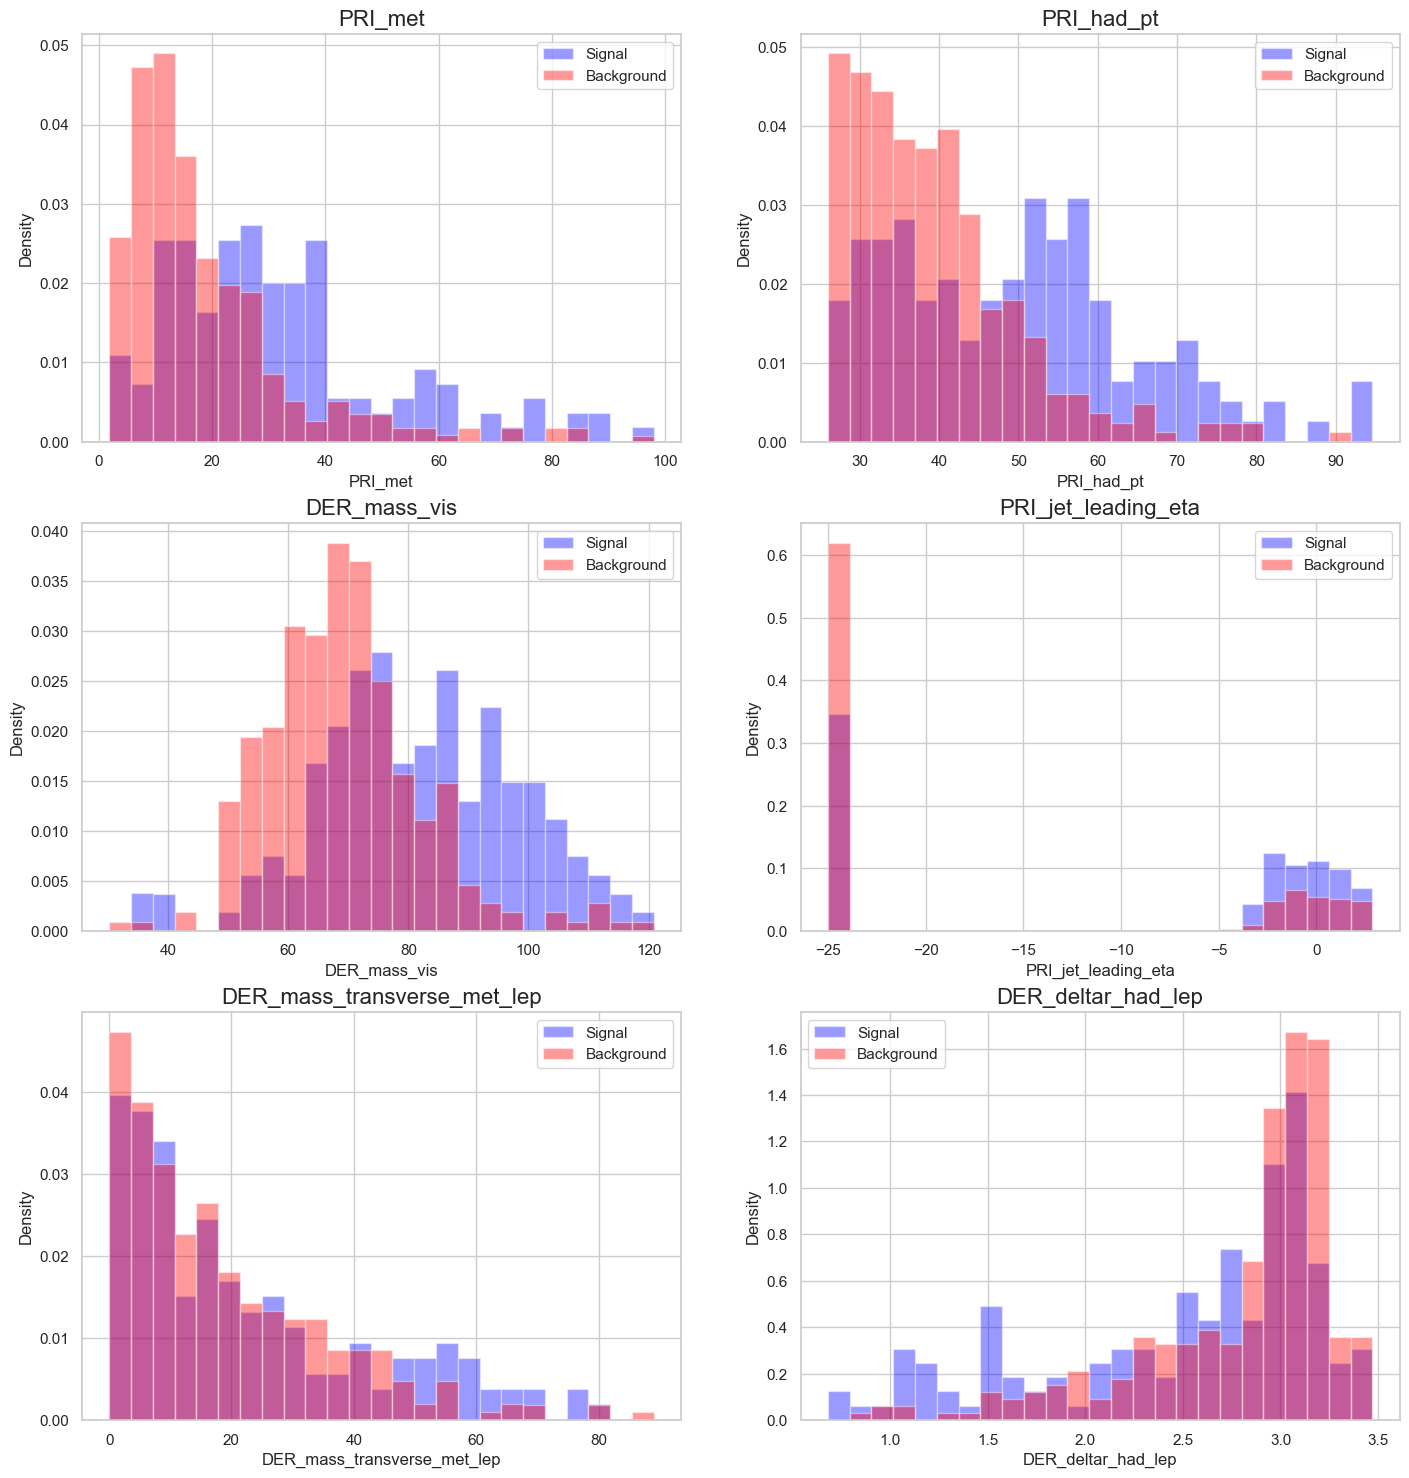

In [11]:
# Show data summary
train_visualize.histogram_dataset()

### Stacked Histogram

The stacked histogram is a visualization technique used to display the distribution of categories within a dataset for a perticular feature. It is particularly useful when comparing the distribution of different groups or classes.

diboson (1,)
diboson (1,)
htautau (30,)
ttbar (18,)
ttbar (18,)
ztautau (289,)
ztautau (289,)


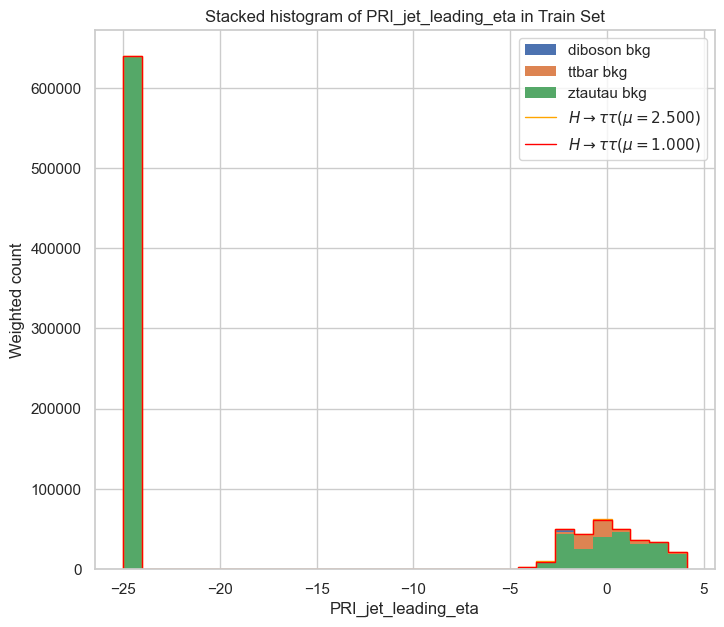

In [12]:
train_visualize.stacked_histogram("PRI_jet_leading_eta",mu_hat=2.5)

/home/chakkappai/miniconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:186: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  figlegend = self._figure.legend(handles, labels, **kwargs)


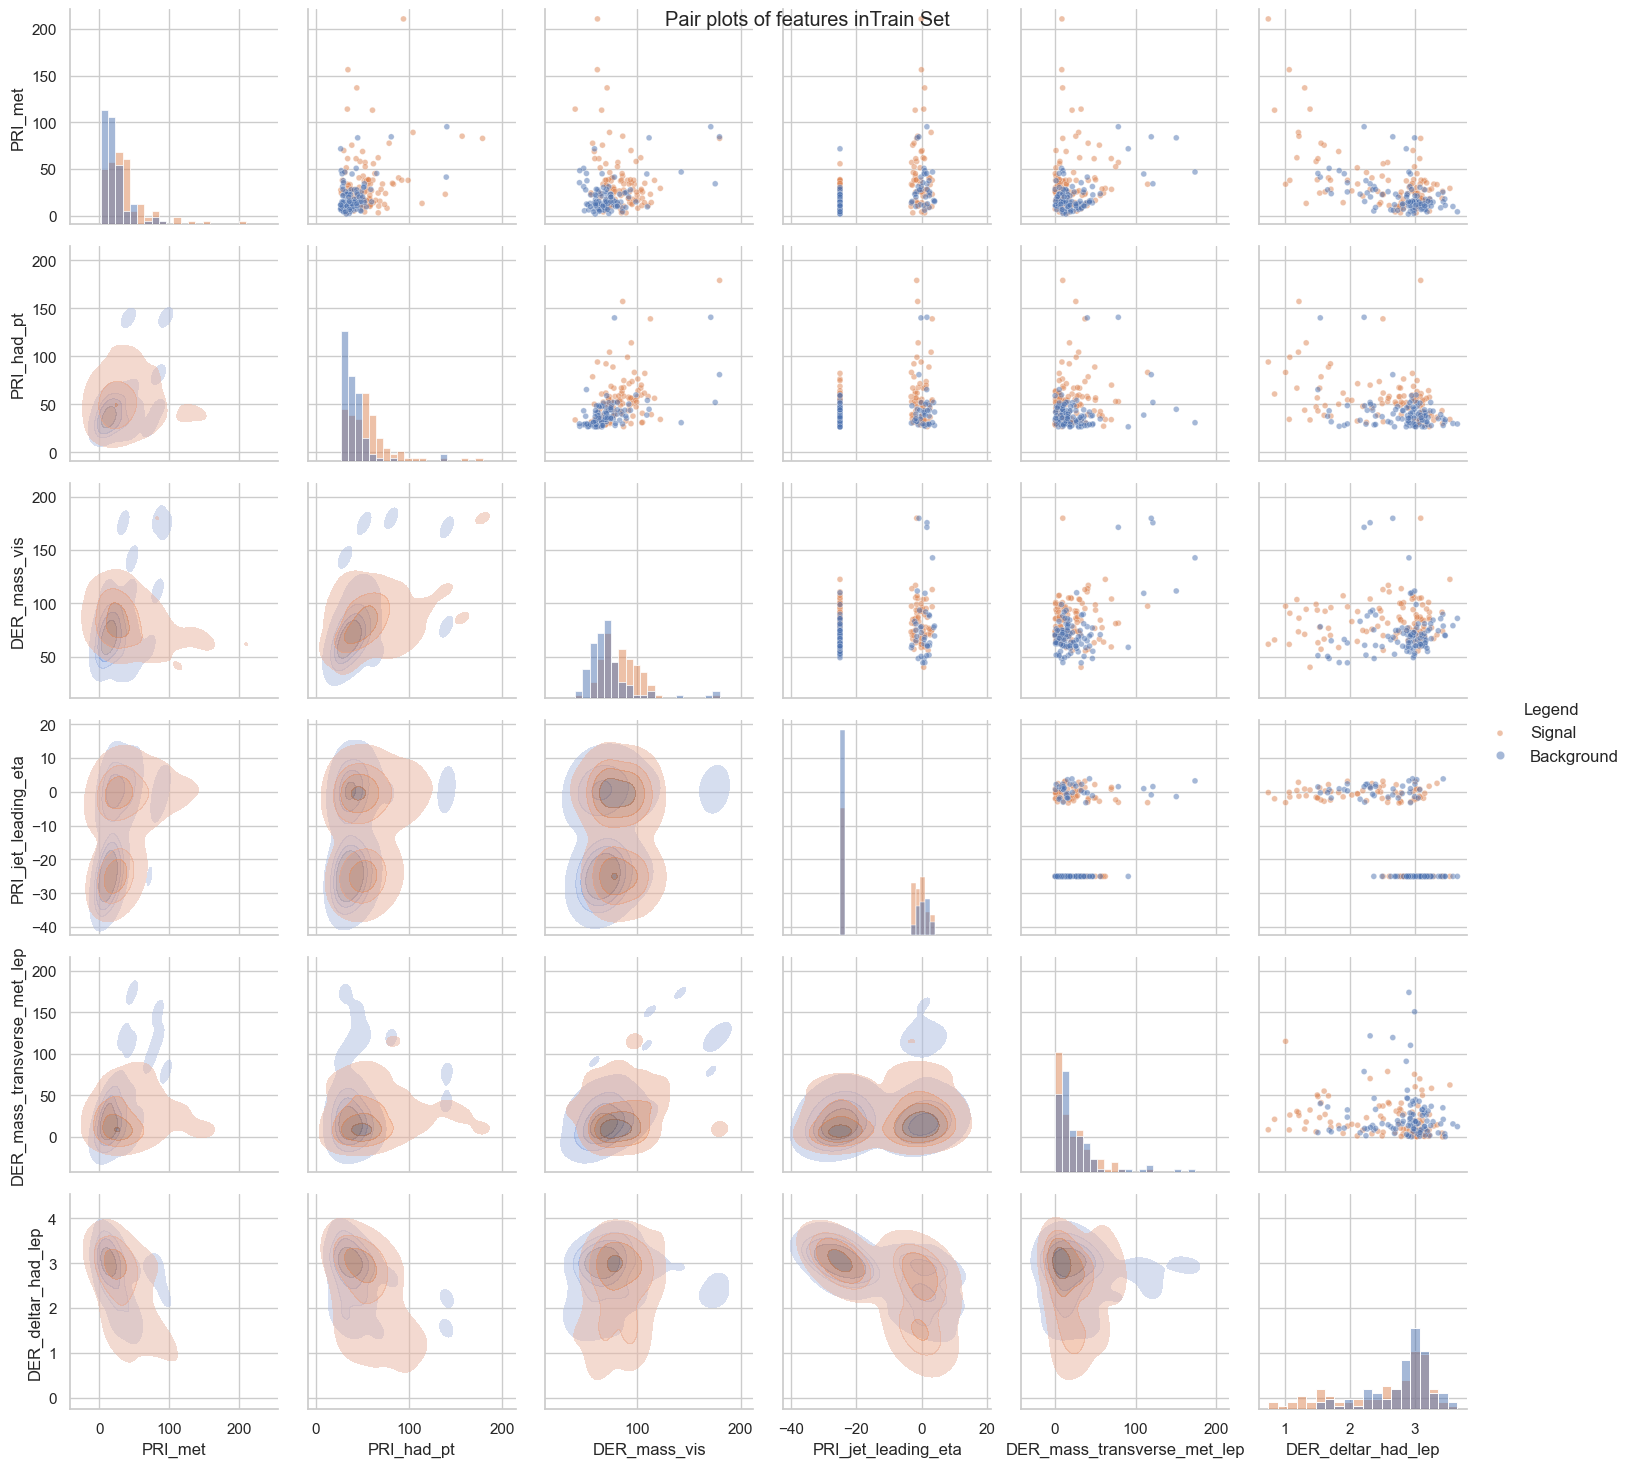

In [13]:
train_visualize.pair_plots(sample_size=100)

In [14]:
""" 
when No systematics parameters are passed, and dopostprocess is True .
This mean derived quantities are calculated and Post process cuts are applied
"""
syst_train_data = systematics(data_vis,tes=0.9, dopostprocess=True) 

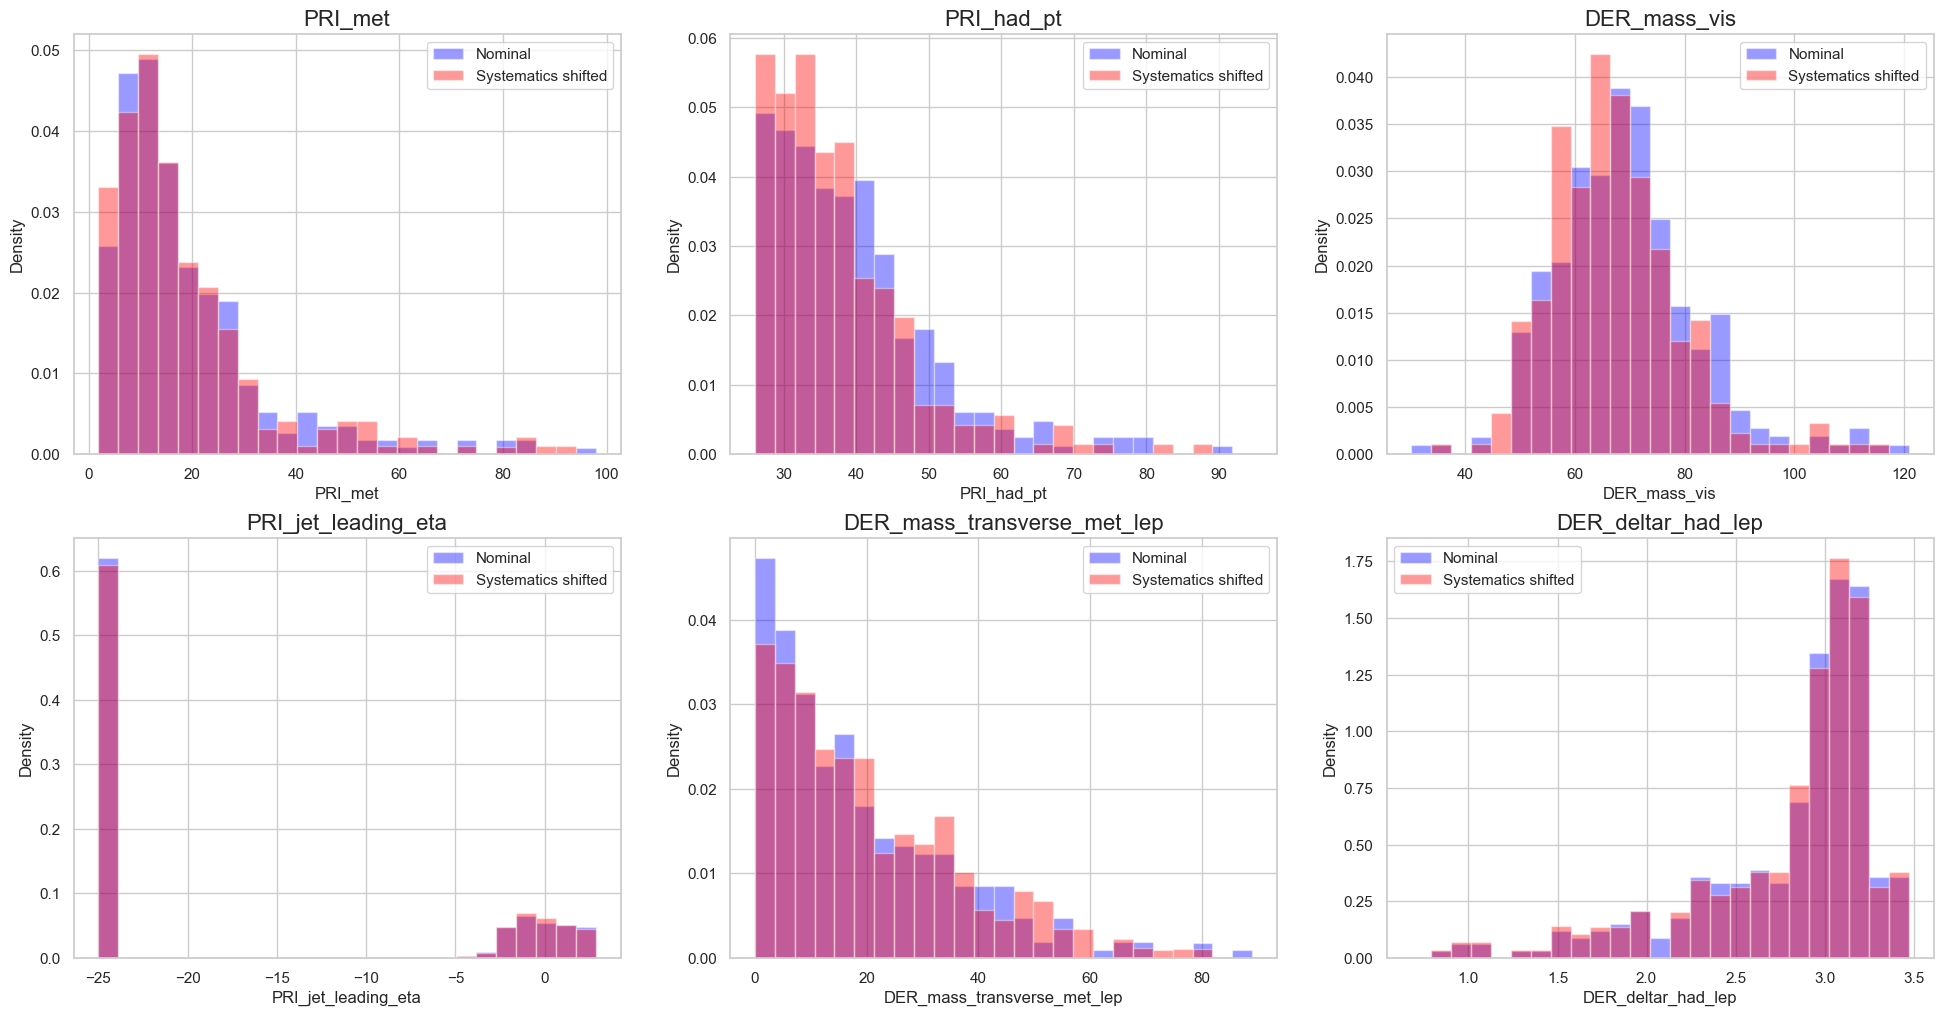

In [15]:
train_visualize.histogram_syst(syst_train_data,syst_train_data['weights'])

For event vise plots we want sytematics plots without without post process cuts

In [16]:
data_vis = data.get_train_set()
# when No systematics parameters are passed, and dopostprocess is false .This mean only derived quantities are calculated
data_vis = systematics(data_vis, dopostprocess=False) 

In [17]:
train_visualize = viz.Dataset_visualise(
    data_set=data_vis,
    columns=[
        "PRI_met",
        "PRI_had_pt",
        "DER_mass_vis",
        "DER_mass_transverse_met_lep",
        "DER_deltar_had_lep",

    ],
    name="Train Set",
)


General Structure of the data object is a dictionary
+-----------------------------+-----------------------+-------------------------------------+
| Key                         | Value                 | Type                                |
+=============================+=======================+=====================================+
| PRI_lep_pt                  | Array of shape (500,) | <class 'pandas.core.series.Series'> |
+-----------------------------+-----------------------+-------------------------------------+
| PRI_lep_eta                 | Array of shape (500,) | <class 'pandas.core.series.Series'> |
+-----------------------------+-----------------------+-------------------------------------+
| PRI_lep_phi                 | Array of shape (500,) | <class 'pandas.core.series.Series'> |
+-----------------------------+-----------------------+-------------------------------------+
| PRI_had_pt                  | Array of shape (500,) | <class 'pandas.core.series.Series'> |
+-----

In [18]:
syst_train_data = systematics(data_vis,tes = 0.9, dopostprocess=False)  # you can use other systematics like jes, softmet, etc.

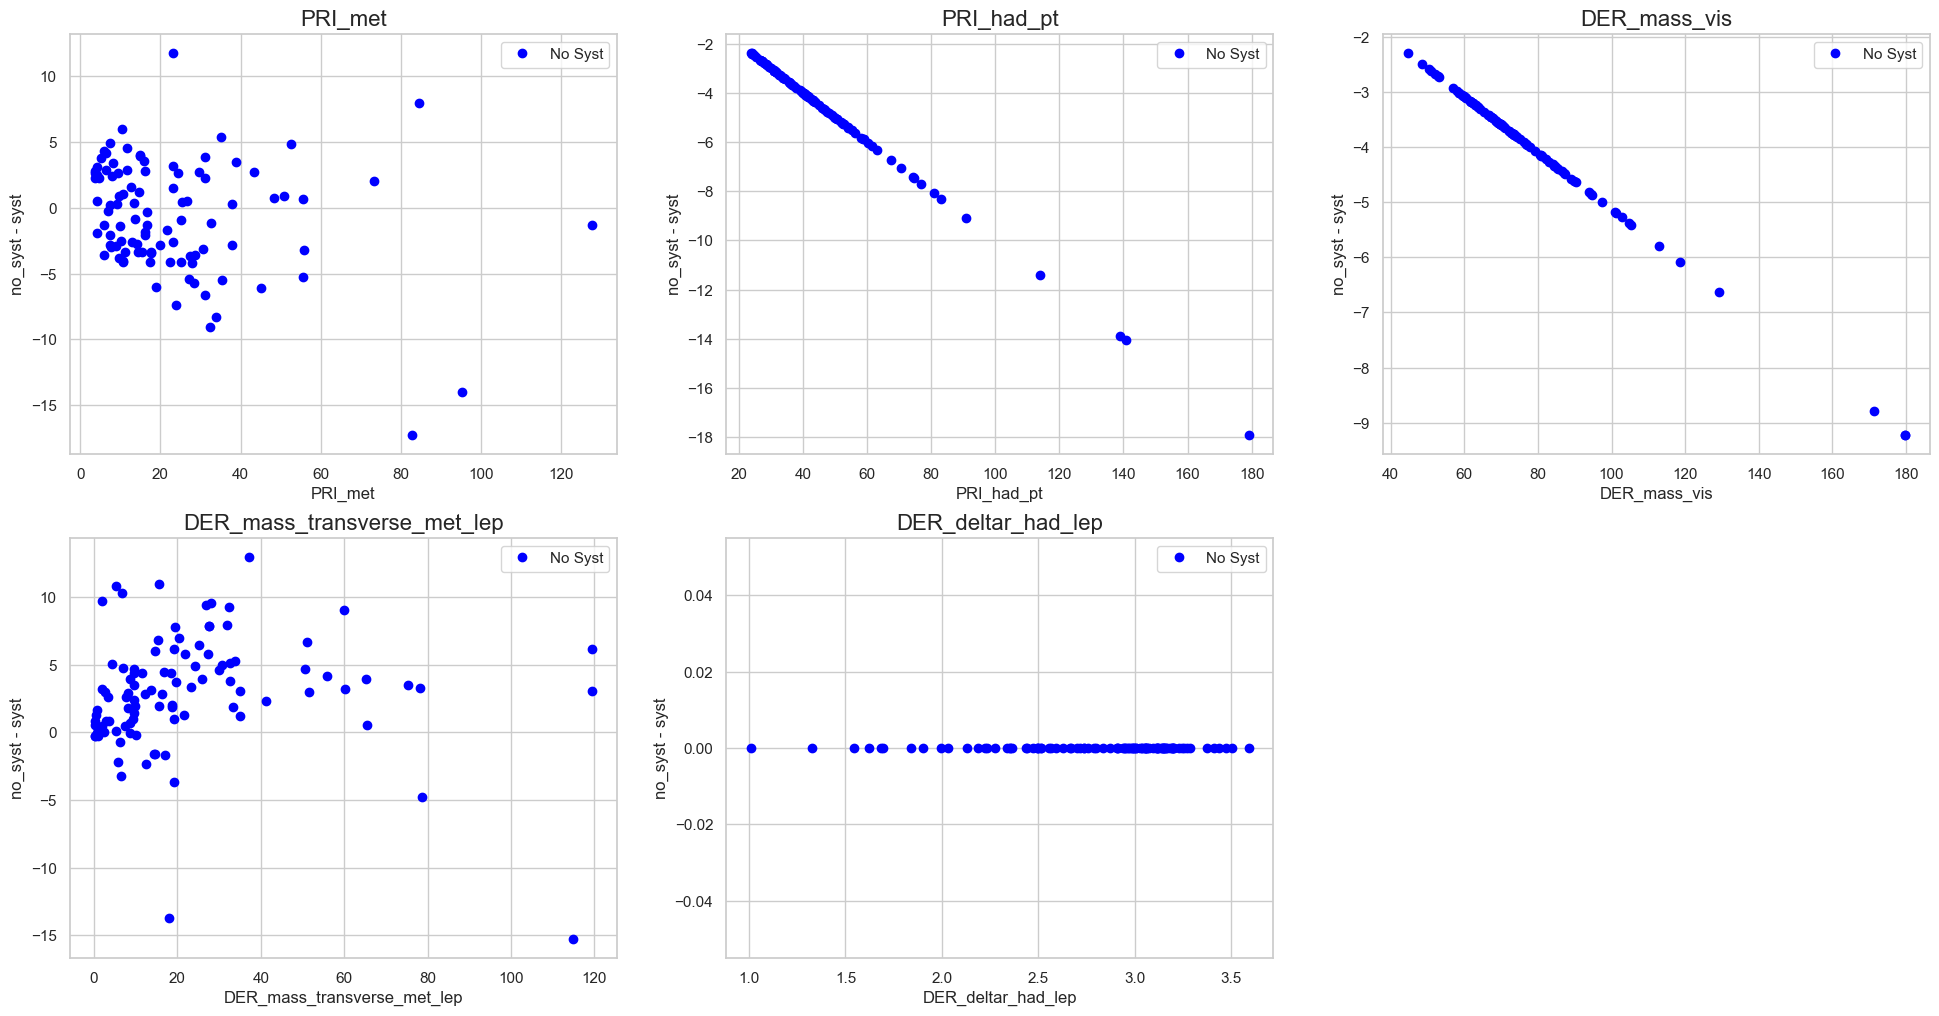

In [19]:
train_visualize.event_vise_syst(syst_train_data)

***
### Program
***


In [20]:

from ingestion import Ingestion

ingestion = Ingestion(data)


***
## MODEL
***
For the competition model should be defined as a class and saved a file called model.py.


***
## The Model Class
***
We import a class named `Model` from the submission file (`model.py`). This `Model` class has the following methods:
- `init`: receives train set and systematics class as input
- `fit`: can be used for training
- `predict`: receives one test set and outputs a dictionary with the following keys
    - `mu_hat` : predicted mu $\hat{\mu}$
    - `delta_mu_hat`: $\Delta{\hat{\mu}}$ bound for $\mu$
    - `p16`: 16th percentile
    - `p84`: 84th percentile

In this example code, the `Model` class implements an XGBoost model which is trained to predict both the TES and the class label. You can find the code in `HEP-Challenge/sample_code_submission/model.py`. You can modify it the way you want, keeping the required class structure and functions there. More instructions are given inside the `model.py` file. If running in Collab, click the folder icon in the left sidebar to open the file browser.

#### ⚠️ Note:
In real setting i.e. the challenge itself, the submitted model is initialized once with train set and systematics class and the `predict` is called multiple times, each time with a different test sets. 

In [21]:
%%writefile sample_submission/model.py

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

class Model:
    def __init__(self, get_train_set=None, systematics=None):
        """
        Parameters:
        - get_train_set (function): A function that returns the training set.
        - systematics (list): systematics paramter

        Attributes:
        - get_train_set (function): A function that returns the training set.
        - systematics (list): A list of systematics.
        - n_bins (int): Number of bins.
        - mu_range (numpy array): Range of mu values.
        - epsilon (float): A small value used for numerical stability.
        - plot (bool): Flag indicating whether to plot the results.
        """
        self.get_train_set = get_train_set
        self.systematics = systematics

        # Default values for other attributes
        self.n_bins = 10
        self.mu_range = np.linspace(0.001, 10.0, 400)
        self.epsilon = 1e-20
        self.plot = True
        
        print("Model initialized with n_bins =", self.n_bins)
        

    def fit(self):
        """
        Trains the model.

        Params:
            None

        Functionality:
            This function can be used to train a model. If `re_train` is True, it balances the dataset,
            fits the model using the balanced dataset, and saves the model. If `re_train` is False, it
            loads the saved model and calculates the saved information. The saved information is used
            to compute the train results.

        Returns:
            None
        """

        # Get the training set
        train_set = self.get_train_set() # train_set is a dictionary with data, labels, and weights

        # Apply systematics to the training set
        train_set = self.systematics(train_set)
        
        print("type of train_set:", type(train_set))
        print("train_set keys:", train_set.keys())
        
        # Separate the signal and background data and weights
        data_sig = train_set.values[train_set["labels"]==1, 0]
        weights_sig = train_set["weights"][train_set["labels"]==1]

        data_bkg = train_set.values[train_set["labels"]==0, 0]
        weights_bkg = train_set["weights"][train_set["labels"]==0]

        # Set the bin range for histogram calculation
        self.bin_range=(
            1.05*min(np.min(data_sig), np.min(data_bkg)),
            0.95*max(np.max(data_sig), np.max(data_bkg))
        )
        
        # Calculate the signal template histogram
        self.template_sig, _ = np.histogram(
            data_sig,
            weights=weights_sig,
            range=self.bin_range, 
            bins=self.n_bins, 
            density=False
        )
        
        # Calculate the background template histogram
        self.template_bkg, _ = np.histogram(
            data_bkg,
            weights=weights_bkg,
            range=self.bin_range, 
            bins=self.n_bins, 
            density=False
        )
        
        


    def predict(self, test_set):
        """
        Predicts the values for the test set.

        Parameters:
            test_set (dict): A dictionary containing the test data, and weights.

        Returns:
            dict: A dictionary with the following keys:
            * 'mu_hat': The predicted value of mu.
            * 'delta_mu_hat': The uncertainty in the predicted value of mu.
            * 'p16': The lower bound of the 16th percentile of mu.
            * 'p84': The upper bound of the 84th percentile of mu.
        """
        # Convert test data and weights to numpy arrays, and select the first column of the data (Lepton_pt)
        test_data = np.array(test_set["data"])[:, 0]
        test_weights = np.array(test_set["weights"])[:]

        # Calculate the histogram of test data
        hist_test, _ = np.histogram(
            test_data,
            weights=test_weights,
            range=self.bin_range, 
            bins=self.n_bins, 
            density=False
        )        

        # Initialize an array to store the negative log-likelihood values
        nll2D = np.zeros((len(self.mu_range)))

        # Iterate over mu values and calculate the negative log-likelihood
        for mu_iter, mu_val in enumerate(self.mu_range):
            N = hist_test + self.epsilon
            nexp = mu_val * self.template_sig + self.template_bkg + self.epsilon

            # Calculate the negative log-likelihood for fixed N, variable nexp
            nll = - (N * np.log(nexp) - nexp)
            nll2D[mu_iter] = np.sum(nll)

        # Calculate the difference between the negative log-likelihood and its minimum value
        nll_diff = nll2D-np.min(nll2D)
        
        # Create a mask to select only NLL values withing 4 of the minimum value for the fit
        fitrange_mask = nll_diff < 4.0
        
        # Fit a parabola to the selected data points
        z = np.polyfit(
            self.mu_range[fitrange_mask], 
            nll_diff[fitrange_mask], 
            2,
        )

        poly = np.poly1d(z)

        deriv1 = poly.deriv()
        
        # Find the minimum value of nll_diff and its corresponding mu value
        min_mu_ind = np.argmin(nll_diff)
        central = self.mu_range[min_mu_ind]

        # Find the extrema of the polynomial and select the minimum value closest to the mu with the minimum nll_diff
        extrema = (deriv1).roots
        minimum = extrema[np.argsort(np.abs(extrema-central))][0]

        # Find the intersections of the polynomial with the threshold value
        # Threadhold 0.5 corresponds to 1 sigma in the chi2 distribution
        threshold = .5
        intersects = (poly - threshold).roots
        
        # Select 2 intersections closest to central value (only needed for polynomials with order > 2)
        intersects = intersects[np.argsort(np.abs(intersects-central))][:2] 

        # Ensure first intersect is smaller than second intersect
        intersects = np.sort(intersects)

        # Plot the results if self.plot is True
        if self.plot:
            fig = plt.figure(figsize=(7,5))
            outer = gridspec.GridSpec(1, 1, wspace=0.2, hspace=0.2)
            subplot = fig.add_subplot(outer[0])

            subplot.plot(self.mu_range, nll_diff, label='Nll_diff')
            subplot.plot(self.mu_range, poly(self.mu_range), label='Fit')
            subplot.set_ylim(-0.0, 4.5)

            subplot.set_ylabel('NLL Difference')
            subplot.set_xlabel('mu')

            subplot.legend()
            plt.show()

        # Create a dictionary to store the results
        result = {
            "mu_hat": minimum,
            "delta_mu_hat": abs(intersects[1] - intersects[0])/2,
            "p16": intersects[0],
            "p84": intersects[1],
        }

        return result



Overwriting sample_submission/model.py


In [25]:
from model import Model 
# import the Model class from the model.py file which was saved from the previous cell

# initialize submission
ingestion.init_submission(Model)

2025-10-15 14:13:35,530 - ingestion            - INFO     - Initializing Submmited Model


Model initialized with n_bins = 10


The `fit_submission` then calls fit method of the model and concludes the training phase of the model

In [26]:

# fit submission
ingestion.fit_submission()

2025-10-15 14:13:37,501 - ingestion            - INFO     - Fitting Submmited Model
2025-10-15 14:13:37,502 - datasets             - INFO     - Selected train size: 700
2025-10-15 14:13:37,506 - datasets             - INFO     - Data loaded successfully


type of train_set: <class 'pandas.core.frame.DataFrame'>
train_set keys: Index(['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta',
       'PRI_had_phi', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_n_jets',
       'PRI_jet_all_pt', 'PRI_met', 'PRI_met_phi', 'weights',
       'detailed_labels', 'labels', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_had', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality'],
      dtype='object')


In [27]:
# load test sets
data.load_test_set() # load the test set to memory, this may take a few seconds

2025-10-15 14:13:39,138 - datasets             - INFO     - Data loaded successfully
2025-10-15 14:13:39,145 - datasets             - INFO     - Test data loaded successfully


### TEST SETTINGS

Here you can set the test settings. This will determine which all systematics are applied and how many pseudo experiments are run

⚠️ Note: As you can see by default *tes* or *Tau-hadron Energy scale systematics* is applied, when running stat-only method turn this to `False` to get meaningfull results.

In [28]:
TEST_SETTINGS = {
"systematics": {  # Systematics to use
    "tes": True, # tau energy scale
    "jes": False, # jet energy scale
    "soft_met": False, # soft term in MET
    "ttbar_scale": False, # ttbar scale factor
    "diboson_scale": False, # diboson scale factor
    "bkg_scale": False, # Background scale factor
    },
"num_pseudo_experiments" : 4 , # Number of pseudo-experiments to run per set
"num_of_sets" : 3, # Number of sets of pseudo-experiments to run
} 


In [29]:
test_settings = TEST_SETTINGS.copy()

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
test_settings[ "ground_truth_mus"] = (np.random.uniform(0.1, 3, test_settings["num_of_sets"])).tolist()

random_settings_file = os.path.join(output_dir, "random_mu.json")
with open(random_settings_file, "w") as f:
    json.dump(test_settings, f)


Next is the prediction phase this is where the pseudo experiments are defined and the model is **repeatedly** called to Evalute each pseudo dataset. 

**⚠️ Note: In the Real Challenge the prediction step is parallelised.**

2025-10-15 14:15:04,028 - ingestion            - INFO     - Calling predict method of submitted model with seed: 31415


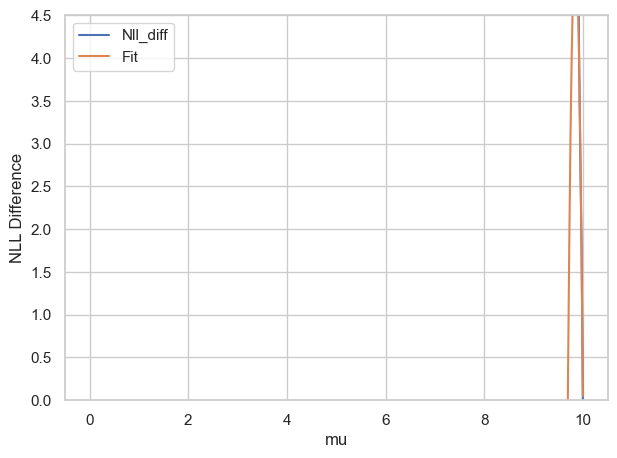

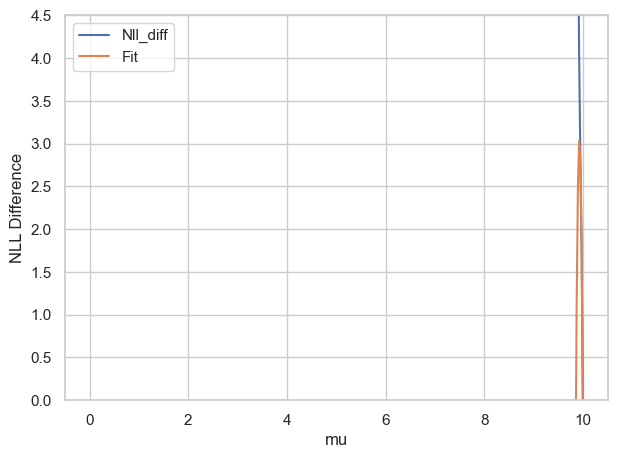

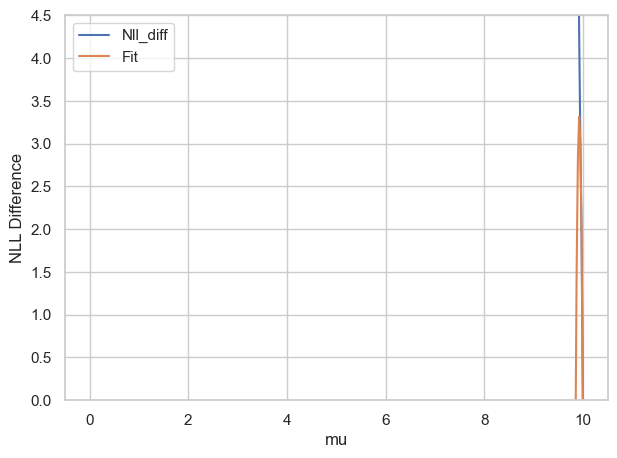

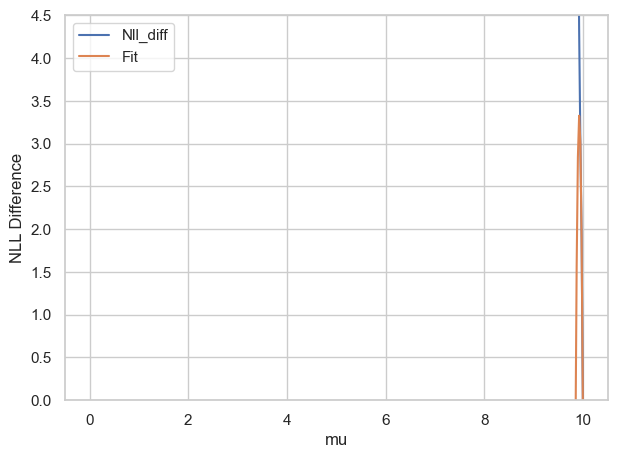

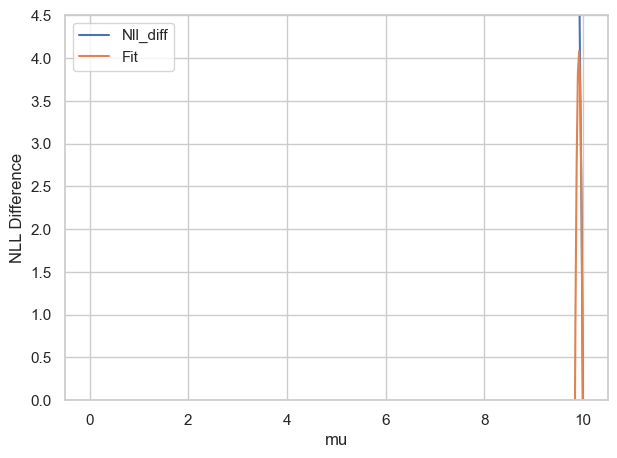

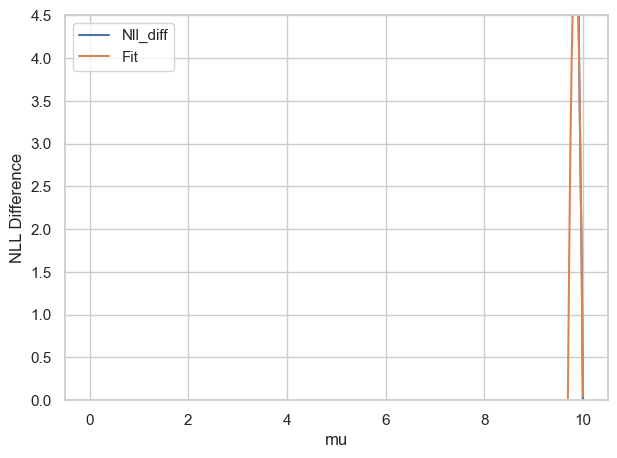

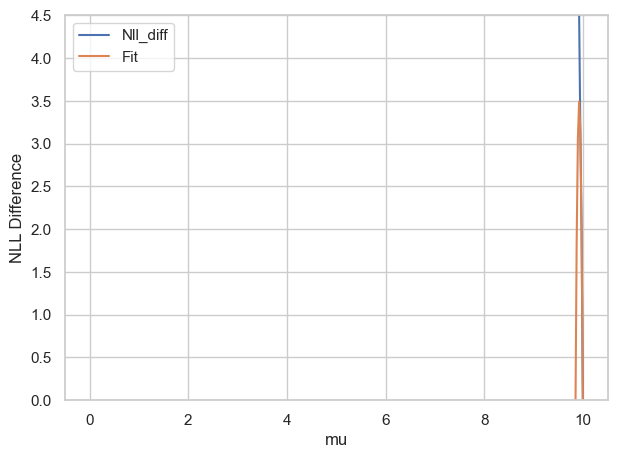

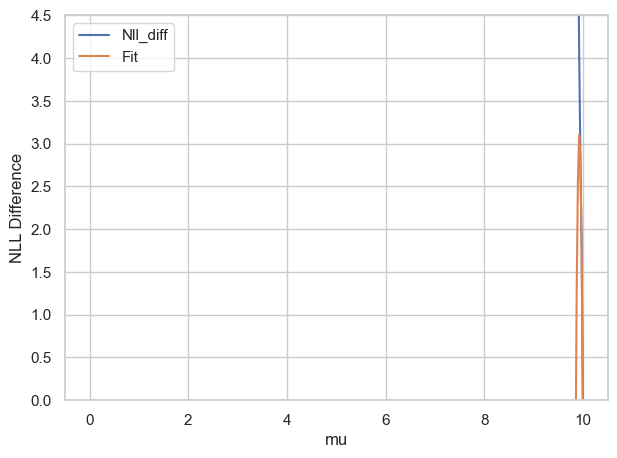

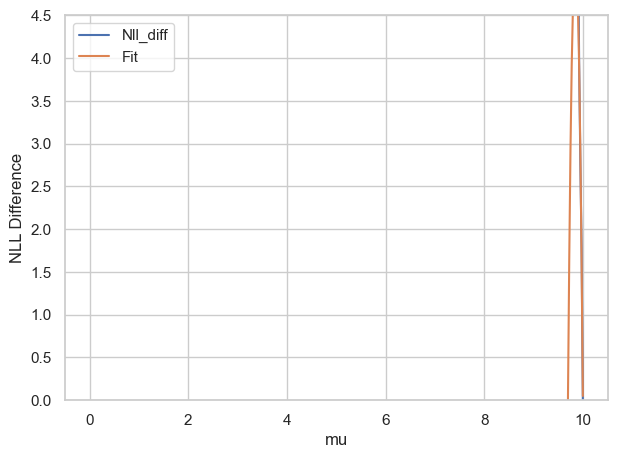

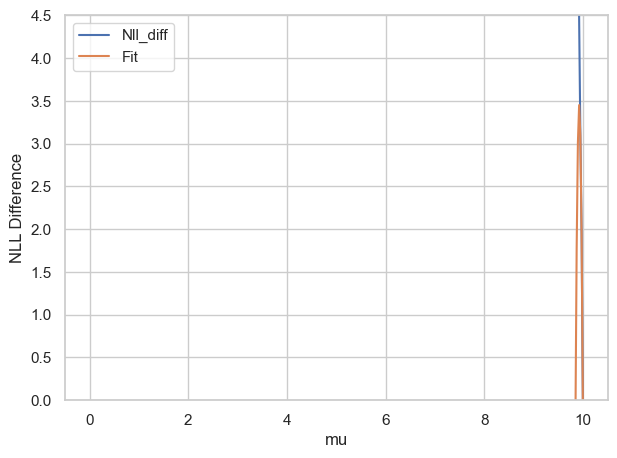

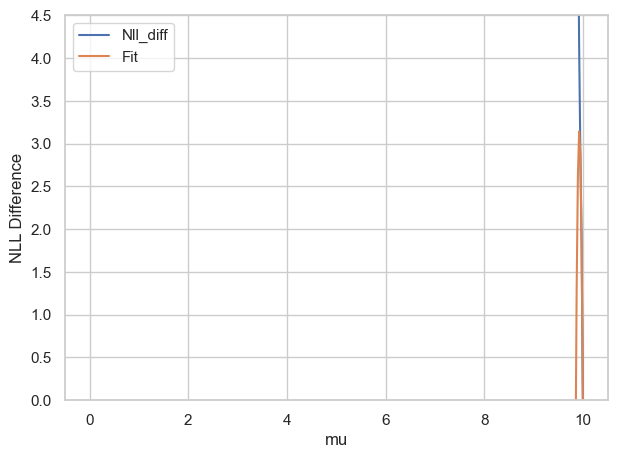

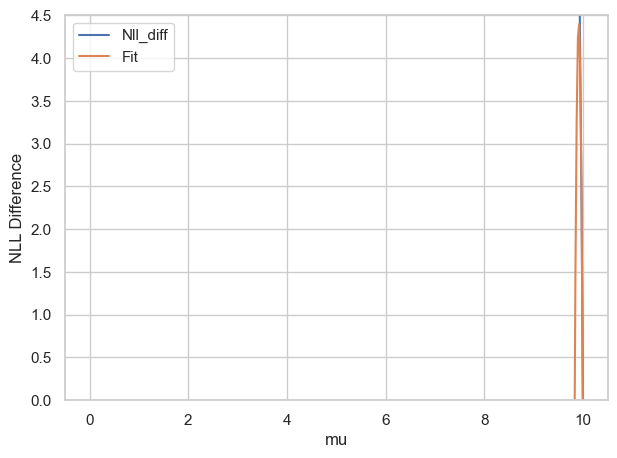

In [31]:

# predict submission
ingestion.predict_submission(test_settings)

The Last step combines the result from all the pseudo experiments and prepare it for scoring.

In [32]:
ingestion.compute_result()

2025-10-15 14:15:22,129 - ingestion            - INFO     - Computing Ingestion Result


In [33]:

# save result
!rm -rf $output_dir/*
ingestion.save_result(output_dir)

***
# Score
***
1. Compute Scores
2. Visualize Scores


In [34]:
from score import Scoring

In [35]:
# Initialize Score
score = Scoring()

In [36]:
score.load_ingestion_results(output_dir)

2025-10-15 14:15:24,641 - score                - INFO     - Read ingestion results from /home/chakkappai/Work/Fair-Universe/HEP-Challenge/sample_result_submission


The next stage computes the score the submitted model by evaluting the results from ingestion.

2025-10-15 14:15:25,086 - score                - INFO     - Computing scores


------------------
Set 0
------------------
MAE (avg): 15.155960330053581
RMSE (avg): 58.42869265359607
Interval: 0.13417527505129012
Coverage: 0.0
Quantiles Score: 1.4359257979679034
------------------
Set 1
------------------
MAE (avg): 18.341791912137445
RMSE (avg): 85.24631621990079
Interval: 0.14091242672841098
Coverage: 0.0
Quantiles Score: 1.387287913837928
------------------
Set 2
------------------
MAE (avg): 18.00292917728952
RMSE (avg): 82.63944461393977
Interval: 0.25022596925173257
Coverage: 0.0
Quantiles Score: 0.8161452579833796


Overall Score
[*] --- RMSE: 75.438
[*] --- MAE: 17.167
[*] --- Interval: 0.175
[*] --- Coverage: 0.0
[*] --- Quantiles score: -2.776
[*] --- Ingestion duration: None
[✔]


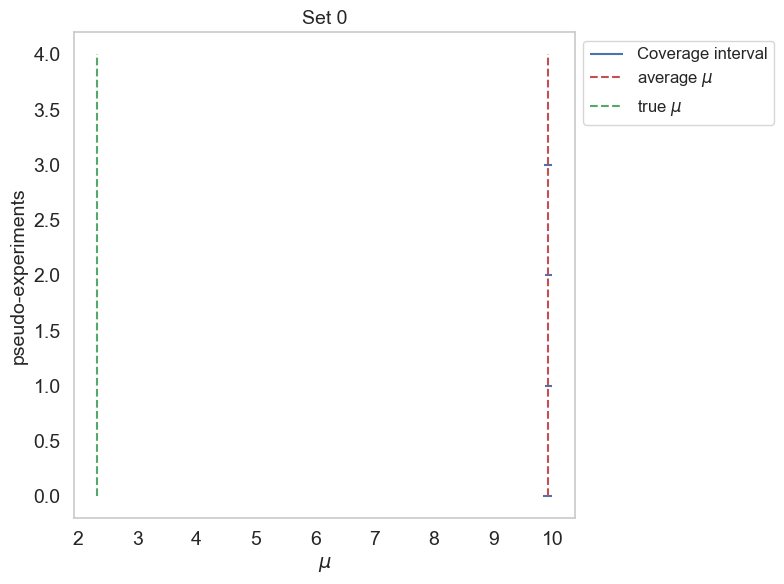

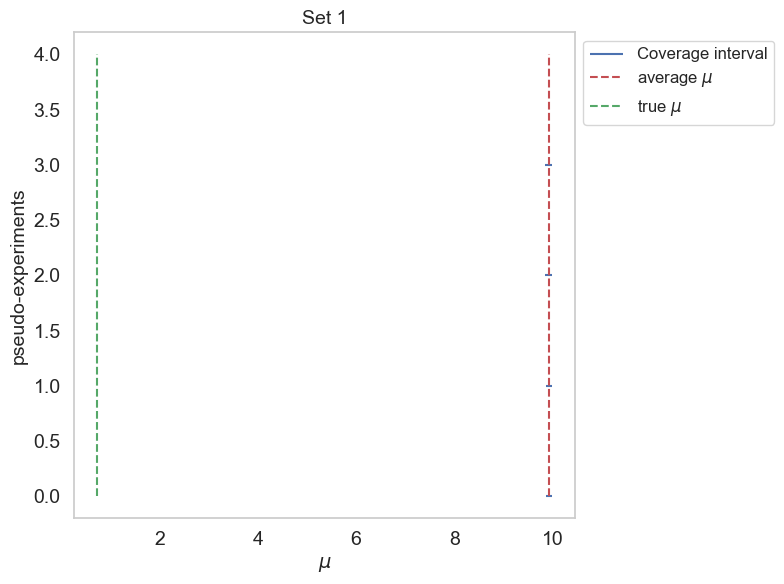

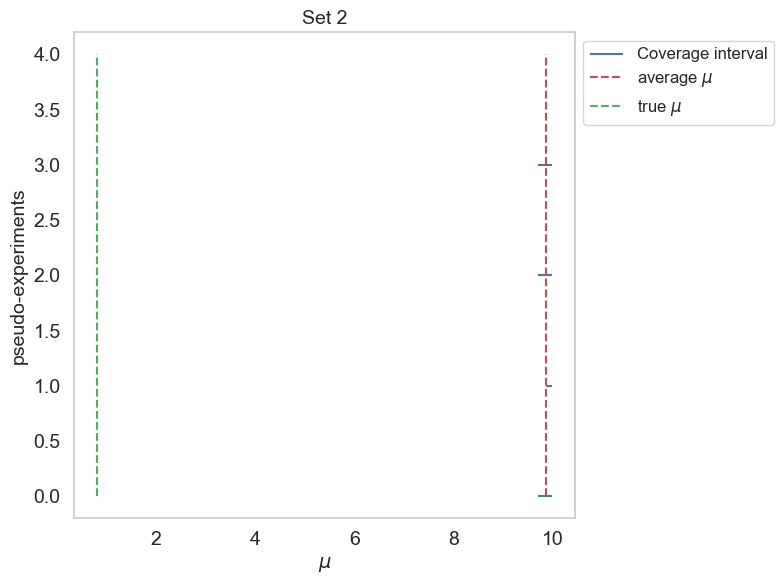

In [37]:
# Compute Score
score.compute_scores(test_settings)

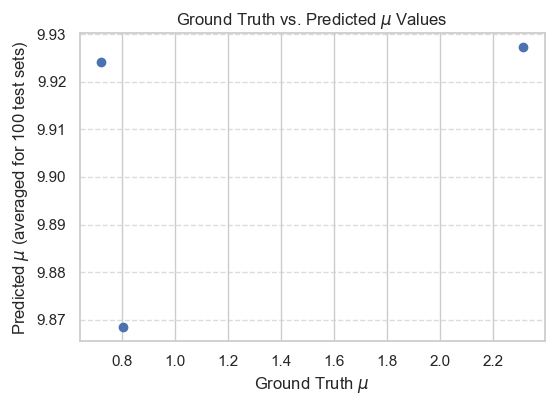

In [38]:
# Visualize scatter plot of ground truth mu and predicted mu
viz.visualize_scatter(ingestion_result_dict=ingestion.results_dict, 
                  ground_truth_mus=test_settings["ground_truth_mus"])

***
# Submission
***

### **Prepare the submission**

In [39]:
def zipdir(archivename, basedir):
    '''Zip directory, from J.F. Sebastian http://stackoverflow.com/'''
    assert os.path.isdir(basedir)
    with closing(ZipFile(archivename, "w", ZIP_DEFLATED)) as z:
        for root, dirs, files in os.walk(basedir):
            # NOTE: ignore empty directories
            for fn in files:
                if fn[-4:] != '.zip' and fn != '.DS_Store':
                    absfn = os.path.join(root, fn)
                    zfn = absfn[len(basedir):]  # XXX: relative path
                    z.write(absfn, zfn)

In [40]:
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
code_submission = 'Submission_' + the_date + '.zip'
zipdir(code_submission, submission_dir)
print("Submit : " + code_submission + " to the competition")
print("You can find the zip file in `HEP-Challenge/")

Submit : Submission_25-10-15-14-15.zip to the competition
You can find the zip file in `HEP-Challenge/
